In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Load electricity generation data
data_folder = Path('./data/')
df = pd.read_excel(data_folder / 'Electricity_Generation_By_Source_Ontario.xlsx')
print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")

                      _      2005      2006      2007      2008      2009  \
0  Hydro / Wave / Tidal  32555.29  32555.29  32555.29  32555.29  32555.29   
1                  Wind   3072.78   3072.78   3072.78   3072.78   3072.78   
2  Biomass / Geothermal    735.10    735.10    735.10    735.10    735.10   
3                 Solar    115.74    115.74    115.74    115.74    115.74   
4               Uranium  81975.00  81975.00  81975.00  81975.00  81975.00   
5           Coal & Coke  28734.08  23808.08  27468.72  22638.21  10461.15   
6           Natural Gas  16885.54  16885.54  16885.54  16885.54  16885.54   
7                   Oil     73.47     73.47     73.47     73.47     73.47   

       2010      2011      2012      2013  ...       2041       2042  \
0  32555.29  34907.29  33887.14  37936.09  ...   39474.29   39452.22   
1   3072.78   3162.68   4007.37   3876.91  ...   75604.97   82983.68   
2    735.10    607.89    672.86    586.34  ...     968.66     955.15   
3    115.74    256

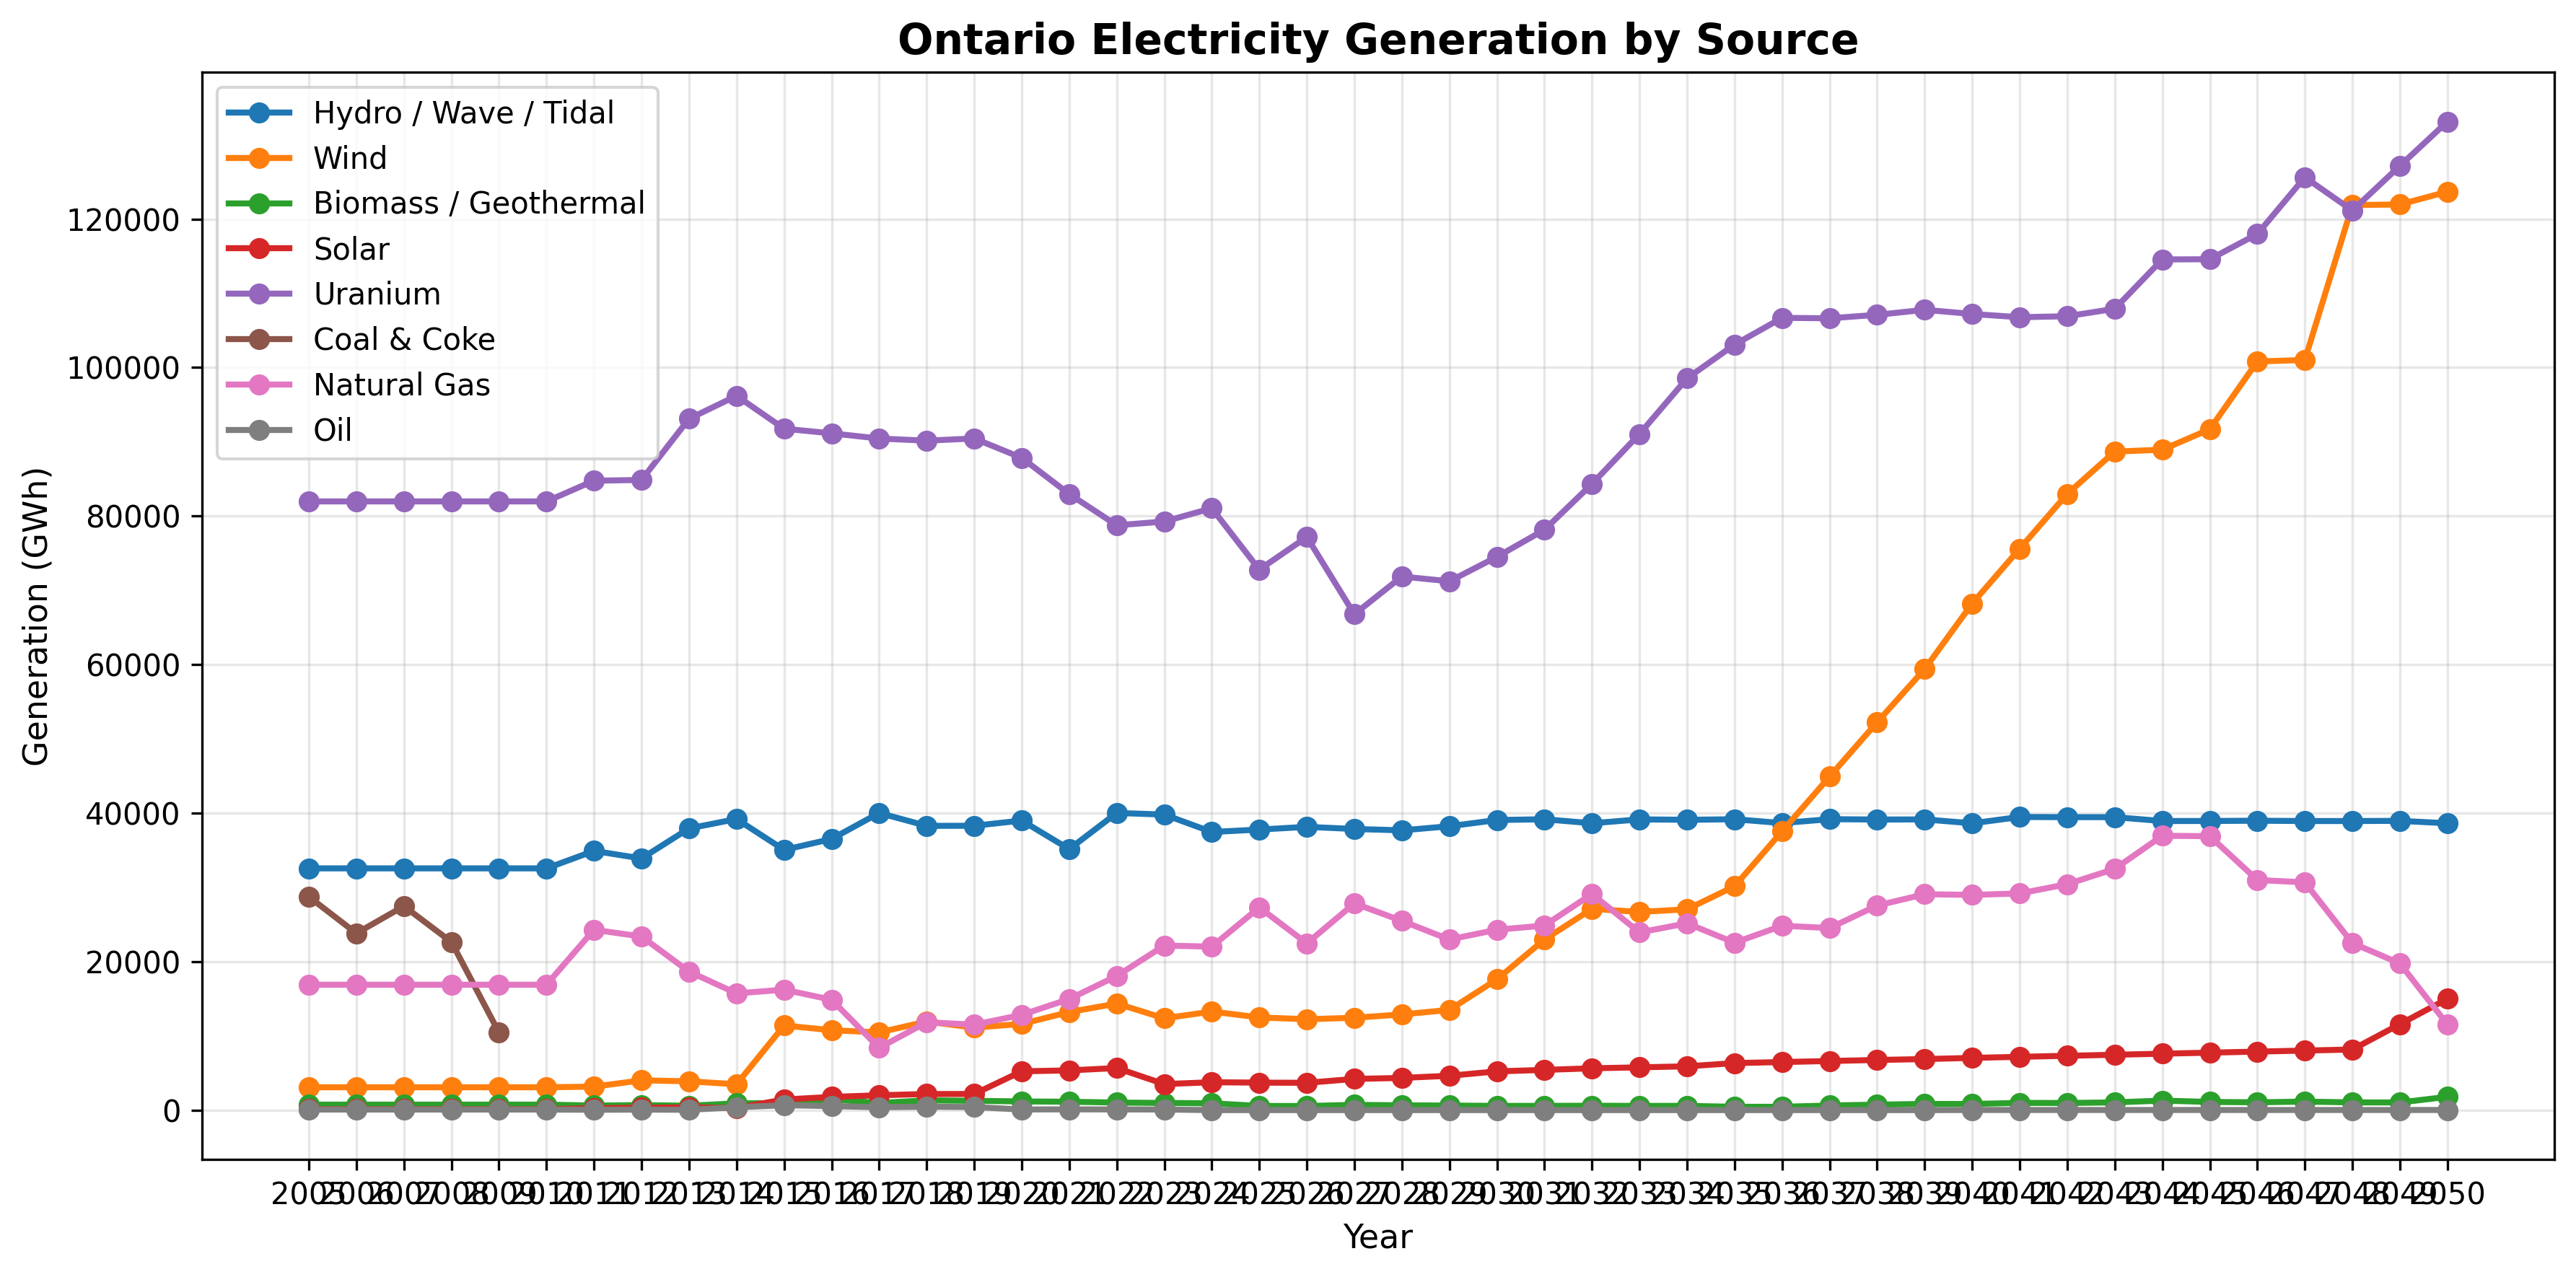

✓ Graph saved


In [5]:
# Simple line graph
df_plot = df.set_index(df.columns[0])

fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

for source in df_plot.index:
    ax.plot(df_plot.columns, df_plot.loc[source], marker='o', linewidth=2, label=source)

ax.set_title('Ontario Electricity Generation by Source', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Generation (GWh)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(data_folder / 'Electricity_Generation_By_Source_Ontario.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Graph saved")

In [ ]:
# Load demand data
demand_df = pd.read_csv(data_folder / 'Combined_Hourly_Demand_2002-2026.csv')
demand_df['Date'] = pd.to_datetime(demand_df['Date'])
demand_df['Year'] = demand_df['Date'].dt.year

# Get yearly total demand
yearly_demand = demand_df.groupby('Year')['Market Demand'].sum().reset_index()
yearly_demand.columns = ['Year', 'Total_Demand']

print("Yearly Demand:")
print(yearly_demand)

# Merge generation data with demand data
df_plot_t = df_plot.T.reset_index()
df_plot_t.columns.name = None
df_plot_t.columns = ['Year'] + list(df_plot.index)
df_plot_t['Year'] = df_plot_t['Year'].astype(int)

merged = df_plot_t.merge(yearly_demand, on='Year')
print("\nMerged data:")
print(merged)

# Filter for every 5 years
years_5yr = list(range(merged['Year'].min(), merged['Year'].max() + 1, 5))
if merged['Year'].max() not in years_5yr:
    years_5yr.append(merged['Year'].max())
    
merged_5yr = merged[merged['Year'].isin(years_5yr)].sort_values('Year')
print(f"\nEvery 5 years: {years_5yr}")
print(merged_5yr)

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

sources = [col for col in merged_5yr.columns if col not in ['Year', 'Total_Demand']]
x = range(len(merged_5yr))
bottom = None

for source in sources:
    if bottom is None:
        ax.bar(x, merged_5yr[source], label=source, width=0.6)
        bottom = merged_5yr[source].values
    else:
        ax.bar(x, merged_5yr[source], bottom=bottom, label=source, width=0.6)
        bottom += merged_5yr[source].values

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Generation (GWh)', fontsize=12, fontweight='bold')
ax.set_title('Ontario Electricity Generation by Source (Every 5 Years)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(merged_5yr['Year'].astype(int))
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(data_folder / 'Electricity_Generation_Stacked_Bar_5yr.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Stacked bar chart saved")